In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'

In [3]:
file1 = f'../data/CMacedonia/{NUTS0}_CMacedonia_WNV_Dataset_NUTS3_2010_2022.csv'
file2 = f'../data/Attica/{NUTS0}_Attica_WNV_Dataset_NUTS3_2010_2022.csv'
file3 = f'../data/Thessaly/{NUTS0}_Thessaly_WNV_Dataset_NUTS3_2010_2022.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)

In [4]:
dataset1.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.215876,40.552658,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,4.435606,6.168909,2.702302,-0.015091,12.092545,6.794681,NaN,NaN,NaN,9.488764,NaN,NaN,NaN,4.083903,NaN,NaN,NaN,2.617253,81.134845,15.306163,25.795942,35.973005,11806.0,44835.0,13866.0,70507.0,11360.0,44584.0,16384.0,72328.0,2016.25,NaN,NaN,1043.454545,0,10083.753176,2604.220647,14,151.983874,145.068848,169.450815,0.0,3.764491,31,83,36,84.0,30,83,12,12,1,6,7,2,0
1,23.139532,40.695359,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,0.175493,0.071702,-0.056915,-0.071702,0.172318,0.088799,-0.032403,-0.088799,0.042514,0.054716,0.077593,0.054716,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,4.816764,7.923406,1.710122,-2.877717,13.860079,6.961915,NaN,NaN,NaN,10.192104,NaN,NaN,NaN,3.731727,NaN,NaN,NaN,1.364895,42.311748,7.807795,13.338001,19.783772,87330.0,375115.0,82051.0,544496.0,84172.0,402246.0,107376.0,593794.0,19627.51,NaN,NaN,740.125984,0,4609.324076,1275.656385,3,156.077628,106.345725,180.535489,0.0,3.928386,31,97,36,97.0,30,97,12,12,1,6,7,2,0
2,22.758634,41.016242,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,0.255218,0.018641,-0.202371,-0.018641,0.264063,-0.000393,-0.237660,0.000393,0.052228,0.059338,0.109973,0.059338,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,3.765541,7.190461,0.340620,-4.895934,12.183407,5.888491,NaN,NaN,NaN,9.151682,NaN,NaN,NaN,2.625300,NaN,NaN,NaN,1.715277,53.173589,9.279576,14.213017,18.993597,5963.0,24603.0,9769.0,40335.0,5680.0,23436.0,11889.0,41005.0,1124.52,NaN,NaN,631.285714,0,14539.491549,1973.650189,5,180.265199,154.698694,180.171598,0.0,10.143914,31,98,36,96.0,30,98,12,12,3,5,8,2,0
3,22.109199,40.888821,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL524,πελλα,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,3.694941,6.414831,0.975051,-3.823409,11.261136,6.293877,NaN,NaN,NaN,8.964341,NaN,NaN,NaN,3.623414,NaN,NaN,NaN,2.628748,81.491186,14.713423,22.905129,32.657020,11159.0,44537.0,14694.0,70390.0,11052.0,43212.0,17690.0,71954.0,1938.34,NaN,NaN,869.318182,0,20467.087760,2556.132830,4,227.370939,344.084297,191.478748,0.0,1.165700,31,86,30,86.0,30,86,10,10,1,6,6,2,0
4,22.441443,40.269748,1,2010,2010-01,EL52,κεντρικη μακεδονια,EL525,πιερια,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,6.091283,8.354315,3.828251,1.550444,15.961111,8.601499,NaN,NaN,NaN,11.918324,NaN,NaN,NaN,5.2846

In [5]:
dataset2.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,23.812763,38.047451,1,2010,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,8.761039,11.580251,5.941828,0.578889,17.782222,10.733185,NaN,NaN,NaN,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,120.039680,25.307650,42.361009,47.792020,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN,2164.888889,0,14600.648385,292.022047,2,182.342684,228.131012,182.543294,0.0,41.287682,32,98,9,99.0,30,98,13,13,10,8,9,2,0
1,23.685082,38.018504,1,2010,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,10.493728,13.860538,7.126918,1.052222,19.014444,12.935874,NaN,NaN,NaN,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,112.130405,23.686240,39.818155,44.482084,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN,2596.888889,0,7655.023708,1575.096836,1,173.398830,66.866135,178.818040,0.0,5.887334,1,98,9,99.0,1,98,13,13,10,8,9,2,0
2,23.754944,37.979104,1,2010,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,9.753346,12.876044,6.630647,0.379474,18.605789,11.901135,NaN,NaN,NaN,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,112.993420,23.831676,39.924151,44.652948,64868.0,377784.0,79042.0,521694.0,61544.0,388717.0,118883.0,569144.0,39021.83,NaN,NaN,2375.526316,0,9967.604261,2195.498040,15,239.898712,262.905206,194.363331,0.0,2.669538,22,89,9,NaN,20,89,13,13,10,8,9,2,9
3,23.749555,37.914897,1,2010,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,9.072484,12.310000,5.834968,-2.668000,19.224000,11.720357,NaN,NaN,NaN,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,110.246915,23.460094,39.829571,44.335911,38993.0,183267.0,41033.0,263293.0,36789.0,199070.0,55549.0,291408.0,12606.74,NaN,NaN,2468.400000,0,2801.690321,1232.926967,4,211.997473,80.771234,191.138144,0.0,3.315736,32,97,9,99.0,30,97,13,13,10,8,9,2,0
4,23.889386,38.042726,1,2010,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,19.416667,21.000000,47.727273,

In [6]:
dataset3.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.719540,39.504234,1,2010,2010-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,3.882783,6.195364,1.570202,-0.969514,15.761316,5.289864,NaN,NaN,NaN,7.935292,NaN,NaN,NaN,2.395366,NaN,NaN,NaN,6.690820,207.415431,41.517169,73.296771,117.810760,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,98.865052,0,17975.604018,1711.707054,3,138.640321,118.625259,179.448305,0.0,3.287901,22,96,9,NaN,20,96,13,13,10,8,9,2,9
1,22.405497,39.703383,1,2010,2010-01,EL61,θεσσαλια,EL612,λαρισα,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,6.047620,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,68.808664,0,20223.103890,2095.505327,0,123.340767,73.893361,179.979366,0.0,2.597098,31,98,36,98.0,30,98,12,12,1,6,7,2,0
2,22.869212,39.281871,1,2010,2010-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,6.674636,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,4.854475,150.488717,29.967839,47.912827,55.731474,15287.0,68105.0,17655.0,101047.0,14898.0,67890.0,22944.0,105732.0,3102.99,NaN,NaN,31.010417,0,3349.163297,962.563555,2,115.090911,25.935036,177.527387,0.0,3.315256,22,85,20,85.0,20,85,9,9,4,1,1,2,0
3,21.719540,39.504234,2,2010,2010-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,4.554370,7.839973,1.268766,-3.042901,13.286678,3.211945,2.916904,NaN,NaN,4.989333,5.921032,NaN,NaN,1.394962,-0.446609,NaN,NaN,11.087217,310.442081,79.217105,151.965634,370.323392,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,445.038062,0,17975.604018,1711.707054,3,138.640321,118.625259,179.448305,0.0,3.287901,22,96,9,NaN,20,96,13,13,10,8,9,2,9
4,22.405497,39.703383,2,2010,2010-02,EL61,θεσσαλια,EL612,λαρισα,0.32133,0.350577,0.083743,-0.350577,0.317564,0.333333,0.063260,-0.333333,0.041787,0.055516,0.075366,0.055516,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,6.868979,11.048597,2.689361,-2.894380,15.076065,6.001348,4.861217,NaN,NaN,10.127192,9.095389,NaN,NaN,1.875504,0.5

In [7]:
dataset = pd.concat([dataset1, dataset2, dataset3])

In [8]:
dataset.shape

(2652, 96)

In [9]:
dataset = encode_cyclical(dataset, 'month', 12)
dataset = convert_multiple_cases(dataset, target_col='cases')

In [10]:
## Simple output binarization

# dataset.drop_duplicates(keep='first', inplace=True, ignore_index=True)
# dataset

In [11]:
dataset.cases.unique()

array([0, 1], dtype=int64)

In [12]:
dataset.shape

(3726, 98)

In [13]:
dataset.rename(columns={"cases": "case"}, inplace=True)

In [14]:
dataset.columns

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [15]:
print(f'Number of NUTS3 Units: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units: 17


In [16]:
dsc = dataframe_describe(dataset, target_column = 'case')
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,181,259,440,11.81%
1,2011,172,91,263,7.06%
2,2012,185,65,250,6.71%
3,2013,186,56,242,6.49%
4,2014,203,2,205,5.50%
5,2015,204,0,204,5.48%
6,2016,204,0,204,5.48%
7,2017,204,0,204,5.48%
8,2018,158,279,437,11.73%
9,2019,176,130,306,8.21%


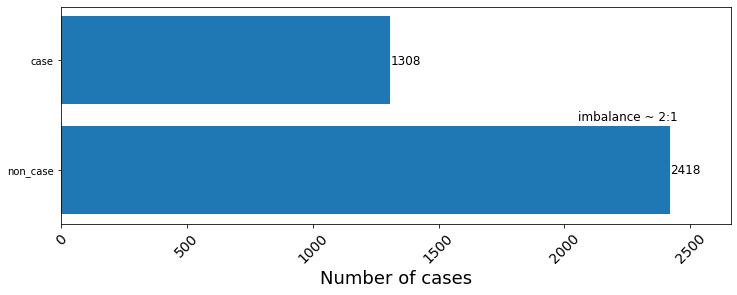

In [17]:
plot_imbalance(dataset, target_column='case')

In [18]:
majority_class = 0
near_u = 0
smote = 00
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = [2014,2015,2016,2017]
features_to_remove = ['x', 'y','month', 'year', 'lc_prop1_assessment','lc_prop2_assessment', 
                      'lc_prop3_assessment', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5',
                      'lw', 'qc']

In [19]:
model_ft_importances = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lst', 'lst_day', 'lst_night', 'monthly_lst_min',
       'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
       'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
       'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'M_Y_LT15', 'M_Y15-64',
       'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'mosq_pred', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_m

In [20]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, 'case', scaler, majority_class, features_to_remove)

    w = calculate_scale_pos_weight(y_train, weight_multiplier)

    model = xgb.XGBClassifier(verbosity=0, seed = 0, device = 'cuda', max_depth = 5, scale_pos_weight = w, objective='binary:logistic', eval_metric = 'logloss')

    trained_model, model_shap = train_tree_model(model, X_train, y_train, explain=True)

    train, test, ft = predict_xgb_model(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, spatial_col = 'NUTS3_NAME')

    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_ft_importances.append(ft)
    model_shaps.append(model_shap)
    
    print(f"Year: {test['year'].iloc[0]} || w:{round(w,3)} || ##")

shap_values= np.concatenate(model_shaps, axis=0)
stacked_ft = np.stack(model_ft_importances, axis=0)
ft_values = np.mean(stacked_ft, axis=0)

Year: 2010 || w:1.358 || ##
Year: 2011 || w:1.178 || ##
Year: 2012 || w:1.143 || ##
Year: 2013 || w:1.134 || ##
Year: 2014 || w:1.227 || ##
Year: 2015 || w:1.227 || ##
Year: 2016 || w:1.227 || ##
Year: 2017 || w:1.227 || ##
Year: 2018 || w:1.407 || ##
Year: 2019 || w:1.213 || ##
Year: 2020 || w:1.187 || ##
Year: 2021 || w:1.125 || ##
Year: 2022 || w:1.378 || ##


In [21]:
feature_names

Index(['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'bio1',
       'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'lst', 'lst_day', 'lst_night', 'monthly_lst_min',
       'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
       'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
       'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
       'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'M_Y_LT15', 'M_Y15-64',
       'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'mosq_pred', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_m

In [22]:
len(feature_names)

79

In [23]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9',
               'bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']

weather = ['lst', 'lst_day', 'lst_night',
           'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean', 'lst_feb_mean',
           'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean', 'lst_feb_day_mean',
           'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_jan_night_mean',
           'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean',
           'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week',
           'acc_rainfall_2week', 'acc_rainfall_jan']

indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
            'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
            'ndbi_std',]

demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']

vectors = ['mosq_pred']

trade = ['L_TOTAL',	'UNL_TOTAL']

economic = ['MIO_EUR']

geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
                    'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
                    'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment', 'lc_prop2',
                    'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment', 'lc_type1',
                    'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc',]

spatiotemporal = ['month_sin', 'month_cos', 'x', 'y','month', 'year',]

In [24]:
len(indicies + weather + demographic + bioclimatic + spatiotemporal + vectors + trade + economic + geomorphological)

92

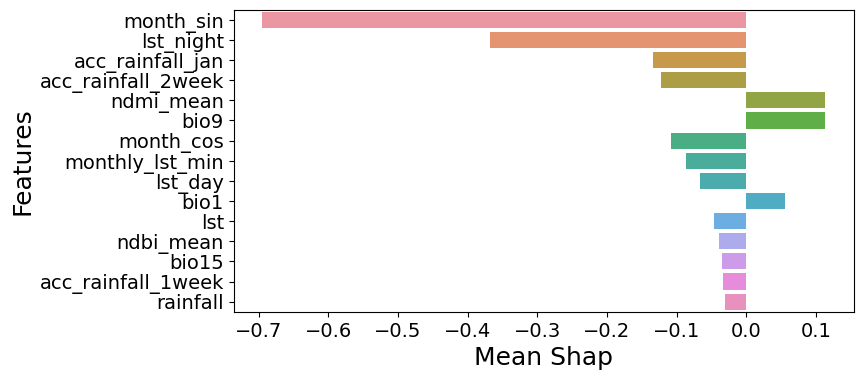

In [25]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

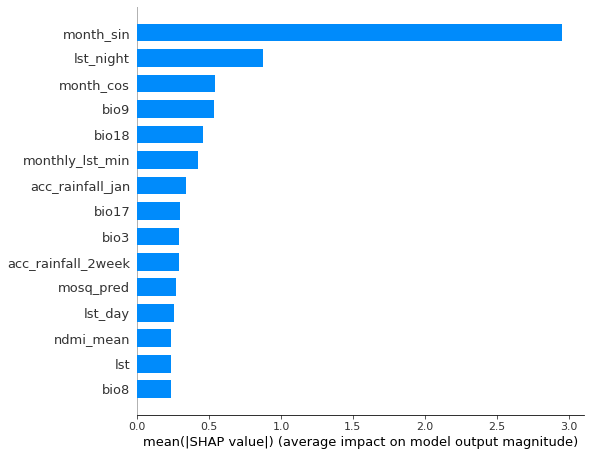

In [26]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

,features,weights
4,spatiotemporal,0.401534
1,weather,0.046292
0,rs_indicies,0.021715
3,bioclimatic,0.019292
5,vectors,0.014120
2,demographic,0.007655
7,economic,0.004157
8,geomorphological,0.003025
6,trade,0.001667


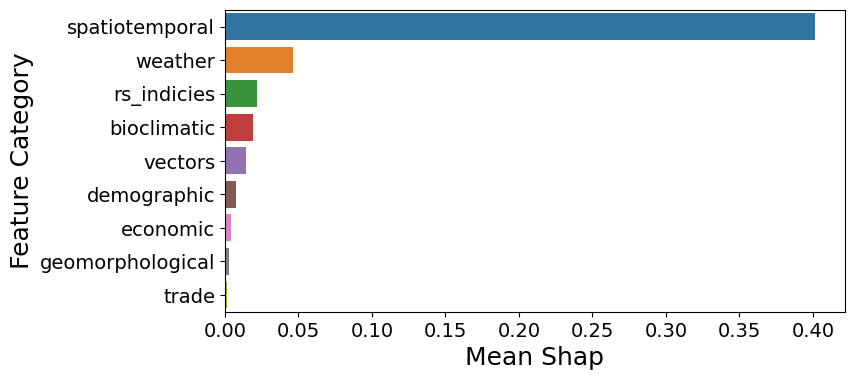

In [27]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_weather = shaps.loc[shaps['features'].isin(weather)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])

categories = {'Category': ['rs_indicies', 'weather', 
                           'demographic', 'bioclimatic', 
                           'spatiotemporal', 'vectors',
                           'trade', 'economic', 'geomorphological'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_weather.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_bioclimatic.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_vectors.weights_abs.mean(),
                            df_trade.weights_abs.mean(),df_economic.weights_abs.mean(),
                            df_geomorphological.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,9)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

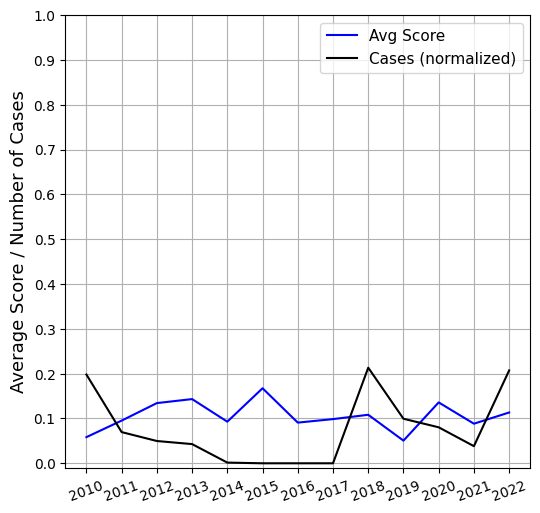

In [28]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

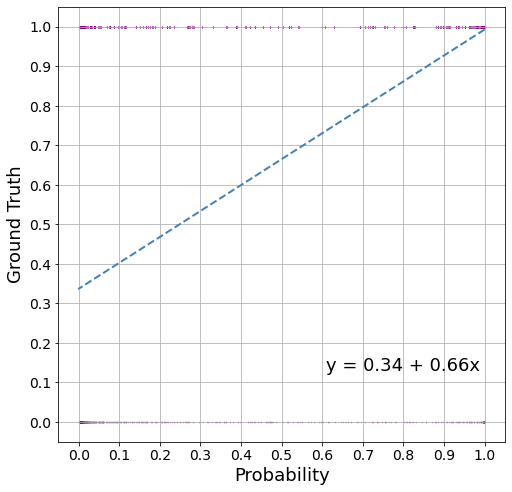

(0.33725922033766725, 0.6555506806680658)

In [29]:
plot_probability_curve(results_test)

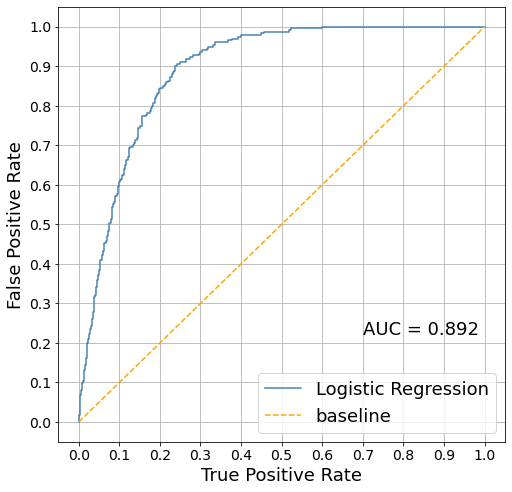

(0.2382, 0.9017, 0.0037, 0.8288)

In [30]:
plot_roc_curve(results_test, plot_gmean=False)

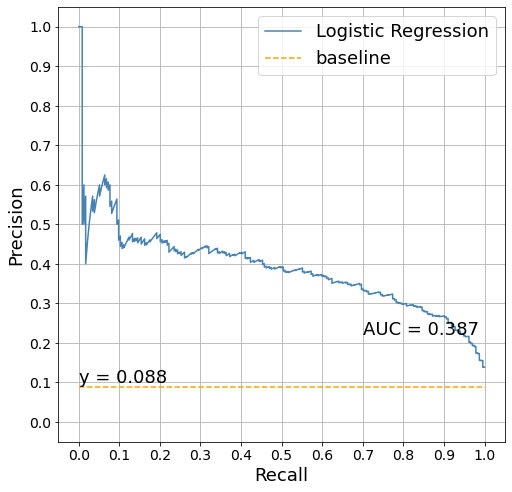

(0.9017, 0.27, 0.0, 0.6123)

In [31]:
plot_pr_curve(results_test, plot_fbeta = False)

In [32]:
results_test

,NUTS3_NAME,month,year,case,score
0,πελλα,8,2013,1,9.999064e-01
1,θεσσαλονικη,8,2018,1,9.998745e-01
2,θεσσαλονικη,8,2015,0,9.998387e-01
3,ημαθια,8,2012,0,9.998325e-01
4,σερρες,8,2018,1,9.997546e-01
...,...,...,...,...,...
2647,σερρες,4,2020,0,1.346652e-06
2648,δυτικος τομεας αθηνων,3,2019,0,1.050015e-06
2649,ανατολικη αττικη,2,2019,0,1.047075e-06
2650,δυτικη αττικη,2,2017,0,8.849721e-07


In [33]:
results_test.head(30)

,NUTS3_NAME,month,year,case,score
0,πελλα,8,2013,1,0.999906
1,θεσσαλονικη,8,2018,1,0.999874
2,θεσσαλονικη,8,2015,0,0.999839
3,ημαθια,8,2012,0,0.999833
4,σερρες,8,2018,1,0.999755
5,χαλκιδικη,8,2013,0,0.999711
6,θεσσαλονικη,8,2013,1,0.999711
7,ημαθια,8,2015,0,0.999701
8,χαλκιδικη,8,2015,0,0.999642
9,πελλα,8,2015,0,0.999639
